In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision timm tqdm scikit-learn matplotlib seaborn



Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/databrain/Training"
TEST_DIR  = "/content/drive/MyDrive/databrain/Testing"

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
def load_vit_model(num_classes):
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=num_classes
    )
    return model.to(device)


In [ ]:
def train_model(model, train_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            loop.set_postfix(
                loss=running_loss / len(train_loader),
                acc=100 * correct / total
            )

    return model


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n✅ Test Accuracy: {acc:.2f}%")

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix – Brain Tumor Classification (ViT)")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return acc



🚀 Training Vision Transformer (ViT-B/16)...



Epoch [5/5]: 100%|██████████| 179/179 [03:30<00:00,  1.18s/it, acc=98.2, loss=0.0581]



✅ Test Accuracy: 97.25%


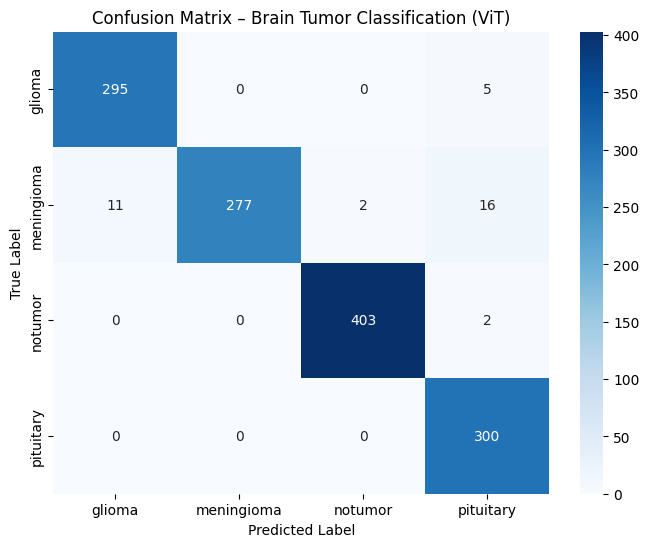


Classification Report:

              precision    recall  f1-score   support

      glioma       0.96      0.98      0.97       300
  meningioma       1.00      0.91      0.95       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.93      1.00      0.96       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



In [ ]:
vit_model = load_vit_model(num_classes)

print("\n🚀 Training Vision Transformer (ViT-B/16)...\n")
vit_model = train_model(vit_model, train_loader, epochs=5)

vit_acc = evaluate_model(vit_model, test_loader)
